In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define path to the pre-processed SMARD dataset
file_path = (
    "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
)

# Verify file existence
if os.path.exists(file_path):
  print("Dataset found successfully! Proceeding with data loading...")
else:
  print(
      "File not found! Please verify the folder structure in your Google Drive."
  )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found successfully! Proceeding with data loading...


 QUANTILE reBAP TAIL-RISK & FINANCIAL IMBALANCE ENGINE
Simulation Horizon:               30 Days (720 Hours)
P10 Pinball Loss:                 0.3845 GW
P50 Pinball Loss (Median):        0.7047 GW
P90 Pinball Loss:                 0.3946 GW
----------------------------------------------------------------------
Mean Hourly Cash Exposure:        €1,540.80
Total Cumulative P&L Drawdown:    €1,109,378.60
Value at Risk (VaR @ 95%):        €35,683.33
Conditional Value at Risk (CVaR): €92,560.22


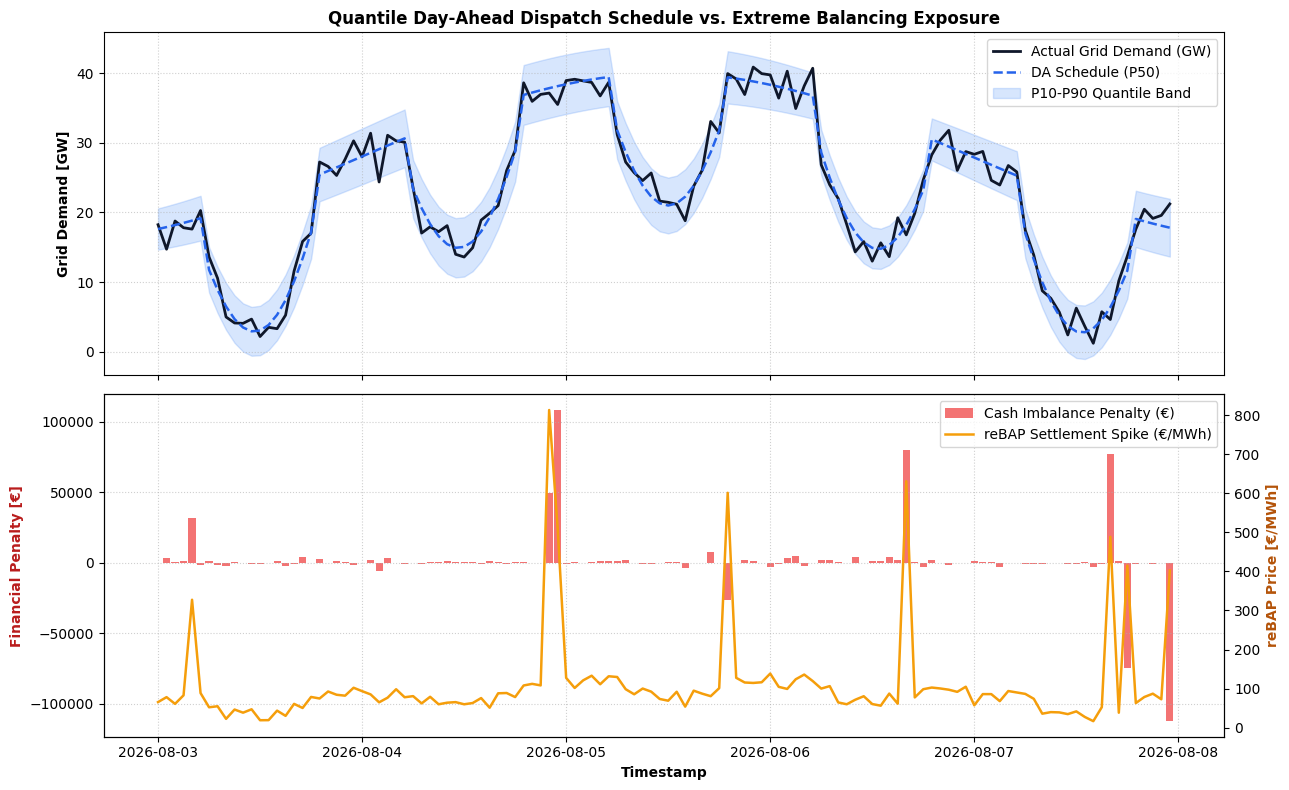

Simulation dataset exported successfully as 'rebap_tail_risk_simulation_2026.csv'


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# ==========================================
# 1. GERMAN MARKET & GRID PROFILE SIMULATION
# ==========================================
dates = pd.date_range(
    start="2026-08-01 00:00:00", periods=24 * 30, freq="h"
)  # 30-Day hourly horizon
np.random.seed(42)
hours = dates.hour.to_numpy()
dayofweek = dates.dayofweek.to_numpy()

# Physics-based Net Demand & Day-Ahead Spot Pricing
solar_shape = np.maximum(0, np.sin((hours - 5) * np.pi / 14)) * 35.0  # GW
wind_shape = (20.0 + 12.0 * np.sin(np.linspace(0, 10 * np.pi, len(dates))))  # GW
base_load = (48.0 + 16.0 * np.clip(np.sin((hours - 6) * np.pi / 12), 0, None)) * np.where(dayofweek >= 5, 0.82, 1.0)

actual_demand_gw = base_load - (solar_shape + wind_shape) + np.random.normal(0, 1.8, len(dates))
da_schedule_gw = base_load - (solar_shape + wind_shape)  # P50 Point Forecast (DA Schedule)

# Day-Ahead Spot Price (EUR/MWh)
da_price_eur = 65.0 + (actual_demand_gw - np.mean(actual_demand_gw)) * 2.2 + np.random.normal(0, 4.0, len(dates))

# Extreme reBAP Settlement Spikes (Simulating Wind Ramp & Thin Liquidity Tail-Risk)
spike_prob = 0.08
rebap_spikes = np.random.choice([0, 1], size=len(dates), p=[1 - spike_prob, spike_prob]) * np.random.uniform(250, 750, len(dates))
rebap_price_eur = da_price_eur + np.random.normal(0, 12.0, len(dates)) + rebap_spikes

df_rebap = pd.DataFrame({
    "timestamp": dates,
    "hour": hours,
    "actual_demand_gw": np.round(actual_demand_gw, 3),
    "da_schedule_gw": np.round(da_schedule_gw, 3),
    "da_price_eur_mwh": np.round(da_price_eur, 2),
    "rebap_price_eur_mwh": np.round(rebap_price_eur, 2)
})

# ==========================================
# 2. ASYMMETRIC QUANTILE FORECAST BANDS
# ==========================================
uncertainty_band = 2.8 + 1.5 * np.abs(np.cos(np.linspace(0, 8 * np.pi, len(dates))))
df_rebap["p10_forecast_gw"] = np.round(df_rebap["da_schedule_gw"] - uncertainty_band, 3)
df_rebap["p90_forecast_gw"] = np.round(df_rebap["da_schedule_gw"] + uncertainty_band, 3)

def pinball_loss(y_true: np.ndarray, y_pred: np.ndarray, quantile: float) -> float:
    error = y_true - y_pred
    return float(np.mean(np.maximum(quantile * error, (quantile - 1) * error)))

p10_loss = pinball_loss(df_rebap["actual_demand_gw"].values, df_rebap["p10_forecast_gw"].values, 0.10)
p50_loss = pinball_loss(df_rebap["actual_demand_gw"].values, df_rebap["da_schedule_gw"].values, 0.50)
p90_loss = pinball_loss(df_rebap["actual_demand_gw"].values, df_rebap["p90_forecast_gw"].values, 0.90)

# ==========================================
# 3. FINANCIAL IMBALANCE P&L & DRAWDOWN
# ==========================================
# Residual MWh (scaled to a 100 MW BRP portfolio)
PORTFOLIO_SCALE_MW = 100.0 / 1000.0  # GW to Portfolio ratio
df_rebap["residual_mwh"] = (df_rebap["actual_demand_gw"] - df_rebap["da_schedule_gw"]) * 1000 * PORTFOLIO_SCALE_MW
df_rebap["spread_eur_mwh"] = df_rebap["rebap_price_eur_mwh"] - df_rebap["da_price_eur_mwh"]

# Cash exposure incurred by BRP due to imbalance settlement
df_rebap["cash_penalty_eur"] = -1.0 * df_rebap["residual_mwh"] * df_rebap["spread_eur_mwh"]

# ==========================================
# 4. TAIL-RISK MODELING: VaR & CVaR (95%)
# ==========================================
CONFIDENCE_LEVEL = 0.95
losses = df_rebap["cash_penalty_eur"][df_rebap["cash_penalty_eur"] > 0].values

var_95 = float(np.percentile(losses, CONFIDENCE_LEVEL * 100))
cvar_95 = float(np.mean(losses[losses >= var_95]))
total_drawdown = df_rebap["cash_penalty_eur"].sum()
mean_exposure = df_rebap["cash_penalty_eur"].mean()

print("=" * 70)
print(" QUANTILE reBAP TAIL-RISK & FINANCIAL IMBALANCE ENGINE")
print("=" * 70)
print(f"Simulation Horizon:               30 Days (720 Hours)")
print(f"P10 Pinball Loss:                 {p10_loss:.4f} GW")
print(f"P50 Pinball Loss (Median):        {p50_loss:.4f} GW")
print(f"P90 Pinball Loss:                 {p90_loss:.4f} GW")
print("-" * 70)
print(f"Mean Hourly Cash Exposure:        €{mean_exposure:,.2f}")
print(f"Total Cumulative P&L Drawdown:    €{total_drawdown:,.2f}")
print(f"Value at Risk (VaR @ 95%):        €{var_95:,.2f}")
print(f"Conditional Value at Risk (CVaR): €{cvar_95:,.2f}")
print("=" * 70)

# ==========================================
# 5. VISUALIZATION & ASSET EXPORT
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
sample_df = df_rebap.iloc[24 * 2 : 24 * 7]  # Sample 5-day view

# Subplot 1: Dispatch Schedule vs Probabilistic Bounds
ax1.plot(sample_df["timestamp"], sample_df["actual_demand_gw"], color="#0F172A", lw=2.0, label="Actual Grid Demand (GW)")
ax1.plot(sample_df["timestamp"], sample_df["da_schedule_gw"], color="#2563EB", lw=1.8, ls="--", label="DA Schedule (P50)")
ax1.fill_between(
    sample_df["timestamp"],
    sample_df["p10_forecast_gw"],
    sample_df["p90_forecast_gw"],
    color="#3B82F6",
    alpha=0.2,
    label="P10-P90 Quantile Band"
)
ax1.set_ylabel("Grid Demand [GW]", fontweight="bold")
ax1.set_title("Quantile Day-Ahead Dispatch Schedule vs. Extreme Balancing Exposure", fontweight="bold", fontsize=12)
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper right")

# Subplot 2: Imbalance Settlement Spikes vs Financial Penalties
ax2.bar(
    sample_df["timestamp"],
    sample_df["cash_penalty_eur"],
    width=0.035,
    color="#EF4444",
    alpha=0.75,
    label="Cash Imbalance Penalty (€)"
)
ax2.set_ylabel("Financial Penalty [€]", fontweight="bold", color="#B91C1C")
ax2.set_xlabel("Timestamp", fontweight="bold")
ax2.grid(True, linestyle=":", alpha=0.6)

ax2_twin = ax2.twinx()
ax2_twin.plot(sample_df["timestamp"], sample_df["rebap_price_eur_mwh"], color="#F59E0B", lw=1.8, label="reBAP Settlement Spike (€/MWh)")
ax2_twin.set_ylabel("reBAP Price [€/MWh]", fontweight="bold", color="#B45309")
ax2_twin.grid(False)

# Merged legend for subplot 2
lines_1, labels_1 = ax2.get_legend_handles_labels()
lines_2, labels_2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.tight_layout()
plt.savefig("rebap_tail_risk_quantile_simulation.png", dpi=300)
plt.show()

# Export simulation dataset
df_rebap.to_csv("rebap_tail_risk_simulation_2026.csv", index=False)
print("Simulation dataset exported successfully as 'rebap_tail_risk_simulation_2026.csv'")